In [1]:
import os
import math
import optuna
import random
import json
import warnings

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import networkx as nx

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, PowerTransformer
from sklearn.preprocessing import RobustScaler, KBinsDiscretizer, FunctionTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from category_encoders import TargetEncoder

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn import set_config

set_config(transform_output="pandas")
seed = 2026
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
warnings.filterwarnings("ignore")

In [2]:
base_path = '/kaggle/input/competitions/playground-series-s6e3'
train_data = pd.read_csv(os.path.join(base_path, 'train.csv'), index_col='id')
test_data = pd.read_csv(os.path.join(base_path, 'test.csv'), index_col='id')
submission = pd.read_csv(os.path.join(base_path, 'sample_submission.csv'))
target_col = 'Churn'

In [3]:
pp_path = os.path.join(base_path, '..', '..', 'datasets', 'domchitdomchit', 'importance-fe')
data_dict = dict()
for _f in os.listdir(pp_path):
    keys = _f.split('.')[0].split('_')[1]
    data_dict[keys] = pd.read_csv(os.path.join(pp_path, _f), index_col=0)

In [4]:
print('train data shape : ', train_data.shape)
print('test data shape : ', test_data.shape)

train_data.head()

train data shape :  (594194, 20)
test data shape :  (254655, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


컬럼명 (Column),번역 (Meaning),설명
gender,성별,남성(Male) 또는 여성(Female)
SeniorCitizen,고령자 여부,고령층 고객인지 여부 (보통 0 또는 1)
Partner,배우자 여부,배우자(파트너)가 있는지 여부
Dependents,부양가족 여부,부양해야 할 가족이 있는지 여부
tenure,재직(유지) 기간,서비스를 이용한 개월 수
PhoneService,전화 서비스,전화 서비스 이용 여부
MultipleLines,다회선 이용 여부,여러 개의 전화 회선을 사용하는지 여부
InternetService,인터넷 서비스,"이용 중인 인터넷 서비스 종류 (DSL, 광랜 등)"
OnlineSecurity,온라인 보안,온라인 보안 서비스 이용 여부
OnlineBackup,온라인 백업,온라인 백업 서비스 이용 여부
DeviceProtection,기기 보호,기기 보상/보호 플랜 이용 여부
TechSupport,기술 지원,기술 지원 서비스 이용 여부
StreamingTV,스트리밍 TV,TV 스트리밍 서비스 이용 여부
StreamingMovies,스트리밍 영화,영화 스트리밍 서비스 이용 여부
Contract,계약 형태,"계약 기간 단위 (월 단위, 1년, 2년 등)"
PaperlessBilling,종이 없는 청구서,전자 청구서(이메일 등) 이용 여부
PaymentMethod,결제 수단,"요금 결제 방법 (신용카드, 자동이체 등)"
MonthlyCharges,월 납부 요금,매달 청구되는 금액
TotalCharges,총 납부 요금,현재까지 납부한 전체 금액
Churn,이탈 여부,(타겟 변수) 서비스를 해지했는지 여부

In [5]:
train_data.info()
print('-'*80, end='\n\n')

cat_col_list = []
num_col_list = []

for _col in train_data.columns:
    if _col == target_col:
        continue
    if train_data[_col].dtype != str:
        if train_data[_col].nunique() < 20:
            cat_col_list.append(_col)
            continue
        num_col_list.append(_col)
        continue
    cat_col_list.append(_col)
train_data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     594194 

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


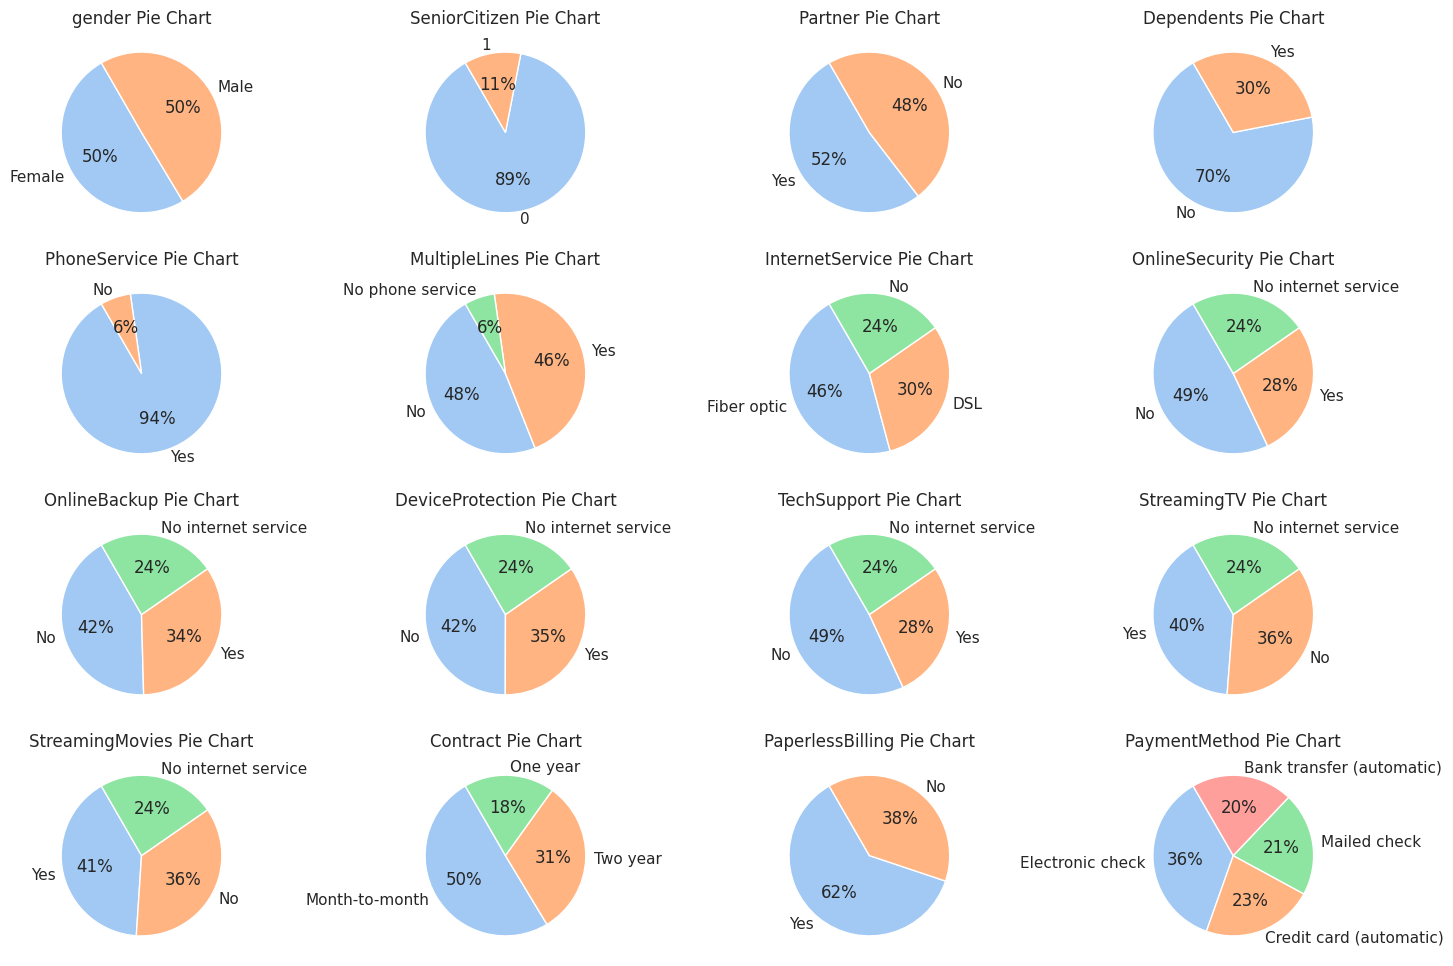

In [6]:
# categorical variable pie chart
sns.set_theme(style="whitegrid")
colors = sns.color_palette('pastel')
fig, axes = plt.subplots(math.ceil(len(cat_col_list)/4), 4, figsize=(18, 12))
axes = axes.flatten()

for _i, _col in enumerate(cat_col_list):
    sample_data = train_data[_col].value_counts(normalize=True)
    axes[_i].pie(sample_data, labels=sample_data.index, colors=colors[:sample_data.__len__()], autopct='%.0f%%', startangle=120)
    axes[_i].set_title(f'{_col} Pie Chart')
for j in range(len(cat_col_list), len(axes)):
    axes[j].axis('off')
# plt.tight_layout()
plt.show()

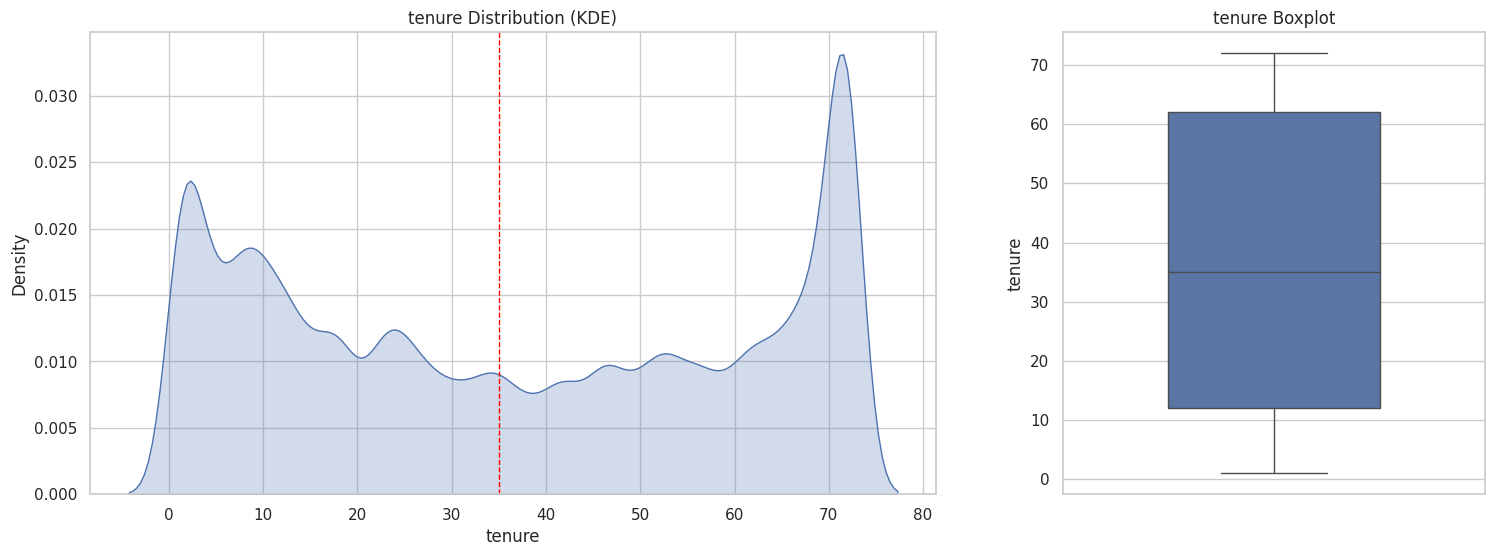

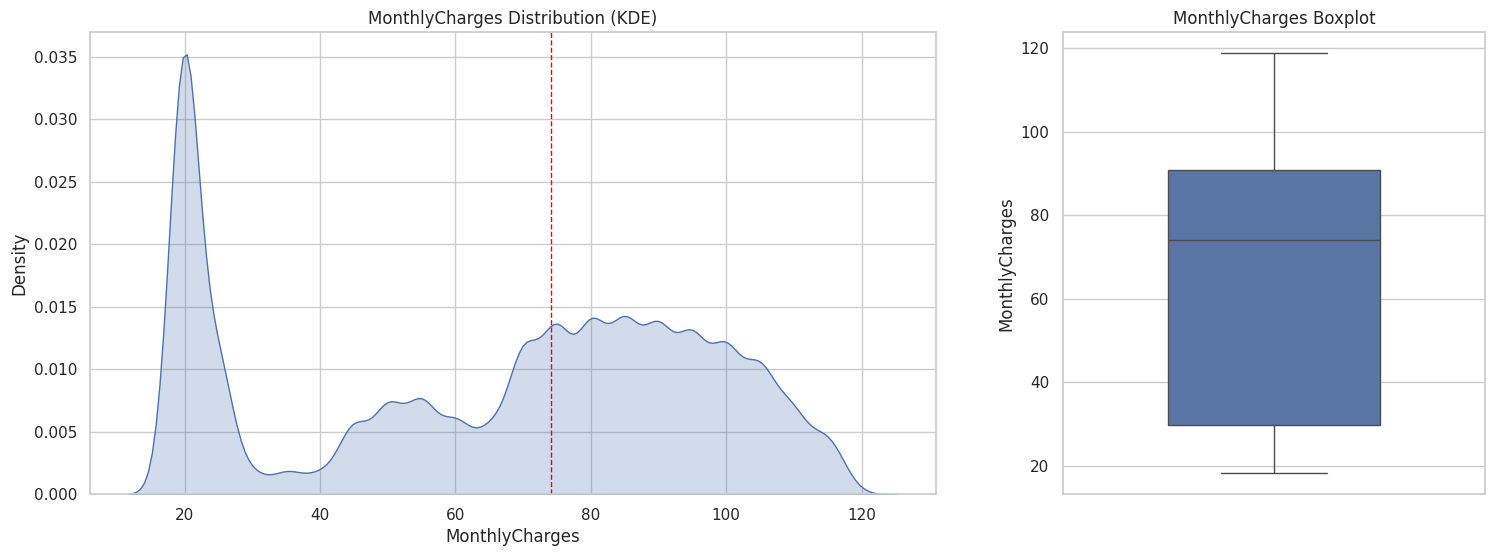

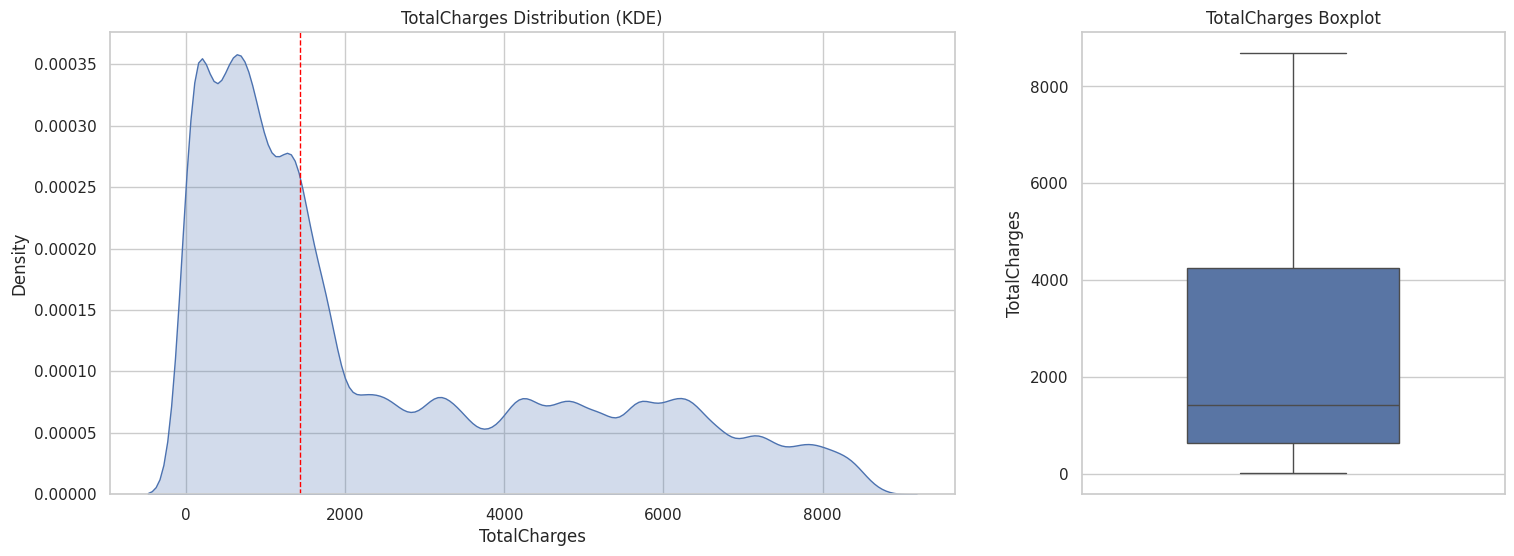

In [7]:
# numerical variable kde-box plot
colors = sns.color_palette('pastel')

# train_data[num_col_list].hist(bins=100, figsize=(16,12))
for _col in num_col_list:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})
    sns.kdeplot(
        data=train_data, x=_col, ax=axes[0], fill=True)
    mid = train_data[_col].quantile(.5)
    axes[0].set_title(f'{_col} Distribution (KDE)', fontsize=12)
    axes[0].axvline(x=mid, color='red', linestyle='--', linewidth=1, label='midian')
    
    sns.boxplot(
        data=train_data, y=_col, ax=axes[1],
        orient='v', width=0.5, linewidth=1, fliersize=3)
    axes[1].set_title(f'{_col} Boxplot', fontsize=12)

    plt.show()

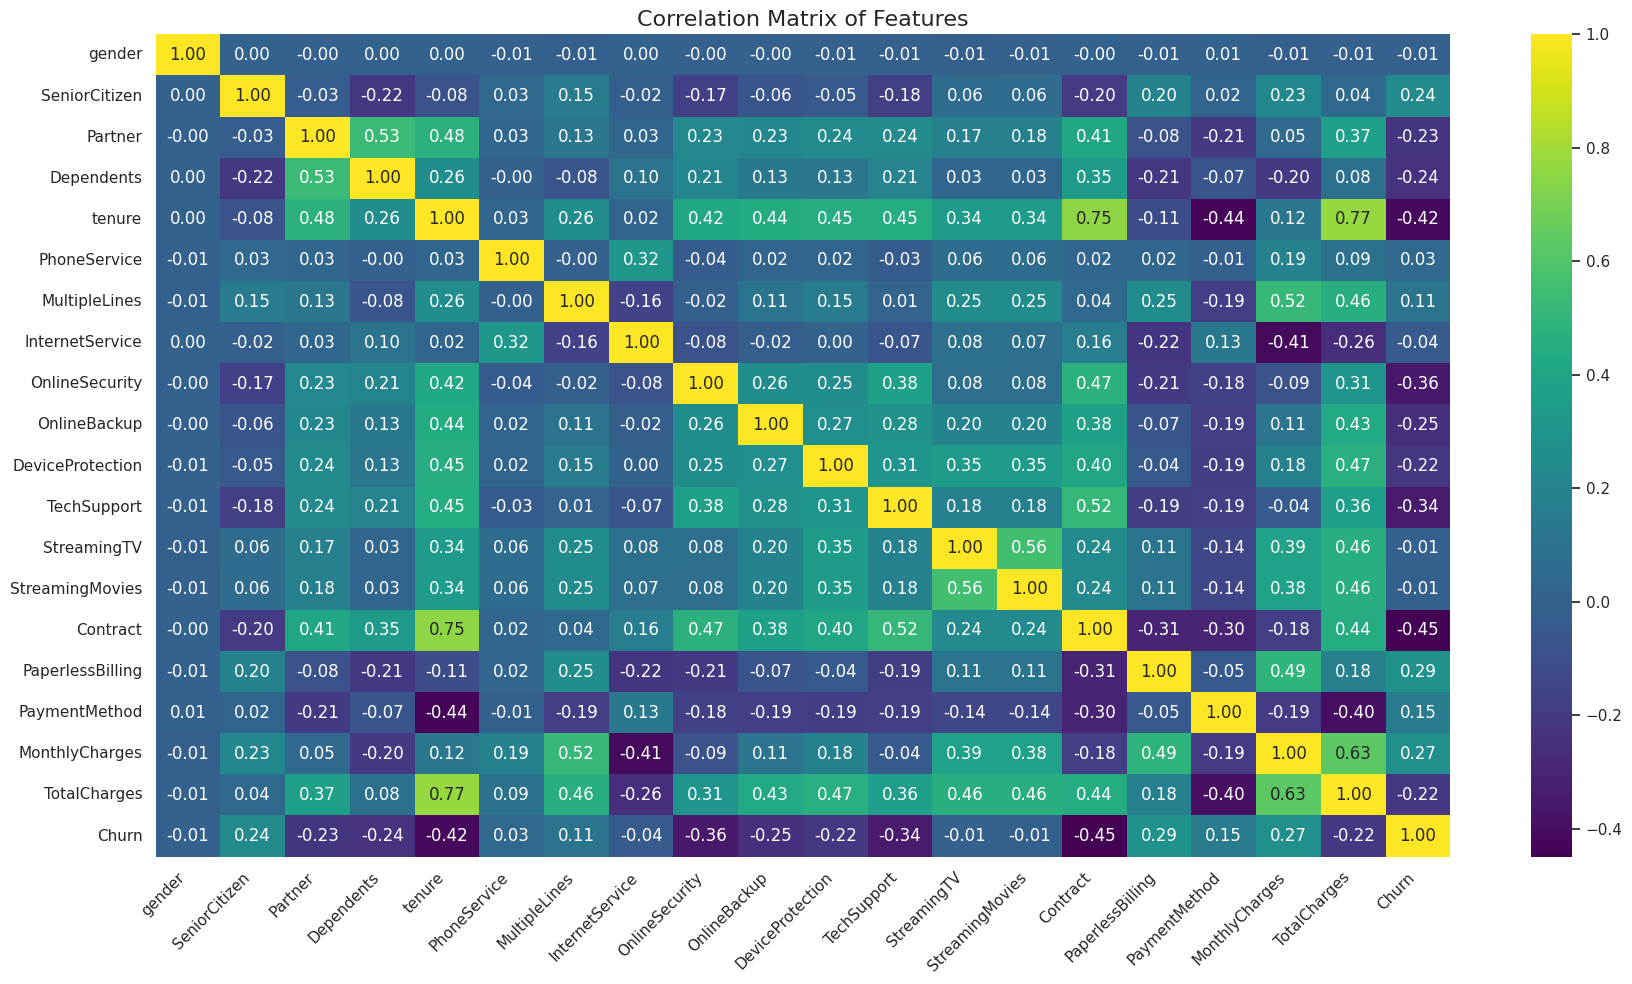

In [8]:
# correlation_matrix
sample = train_data.copy()
for _col in sample:
    if sample[_col].dtype == object:
        le = LabelEncoder()
        sample[_col] = le.fit_transform(sample[_col])
        
correlation_matrix = sample.corr()
plt.figure(figsize=(18, 10)) 
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix of Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

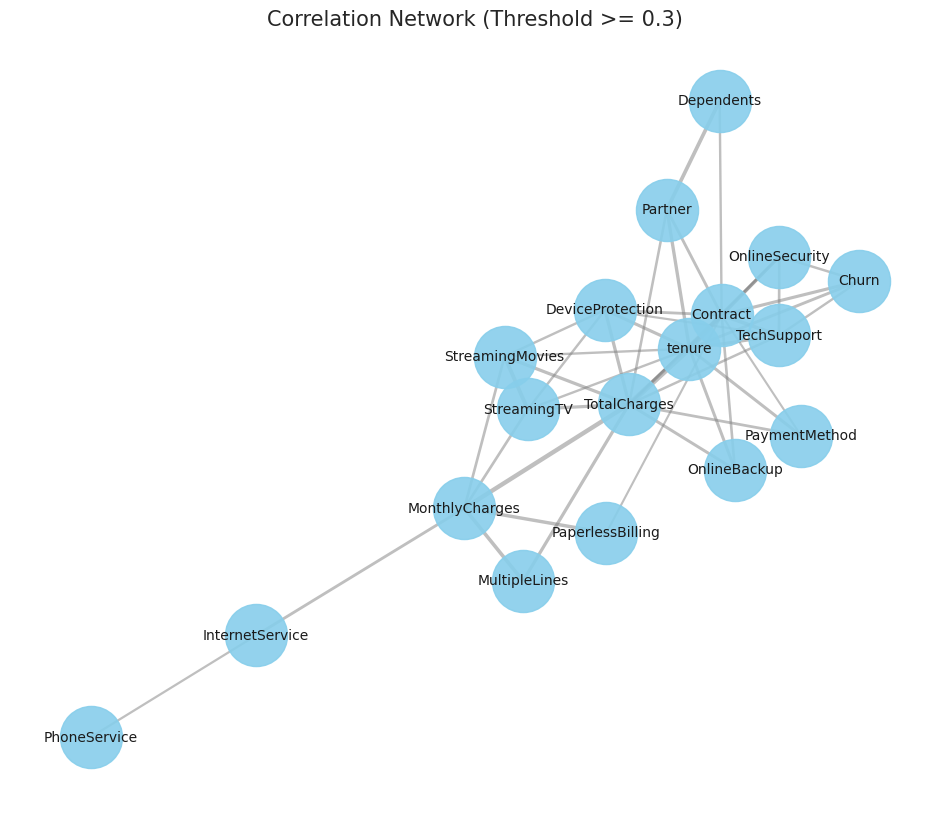

In [9]:
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
corr_series = abs(upper.unstack().dropna())
high_corr = corr_series[corr_series >= 0.3].sort_values(ascending=False)

G = nx.Graph()
for _i in high_corr.items():
    G.add_edge(_i[0][0], _i[0][1], weight=_i[1])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.3, iterations=100, weight='weight', seed=seed) # 노드 배치 알고리즘
# 노드(변수) 그리기
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue', alpha=0.9)

# 연결선(상관계수) 그리기 - 선 두께를 상관계수 크기에 비례하게 설정
edges = G.edges(data=True)
weights = [d['weight'] * 5 for u, v, d in edges] # 시각화를 위해 5배 확대
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title(f"Correlation Network (Threshold >= {0.3})", size=15)
plt.axis('off')
plt.show()

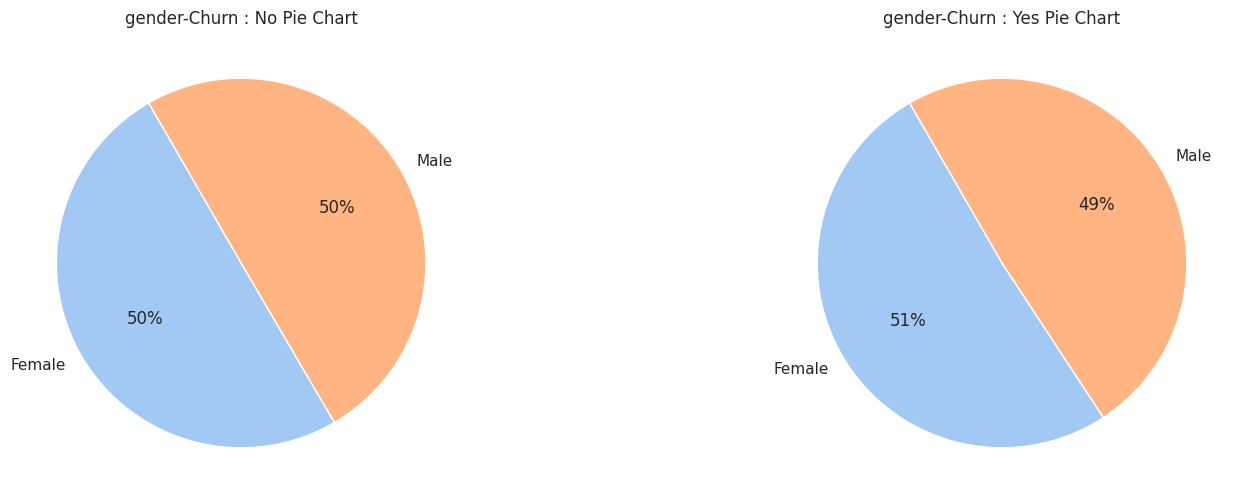

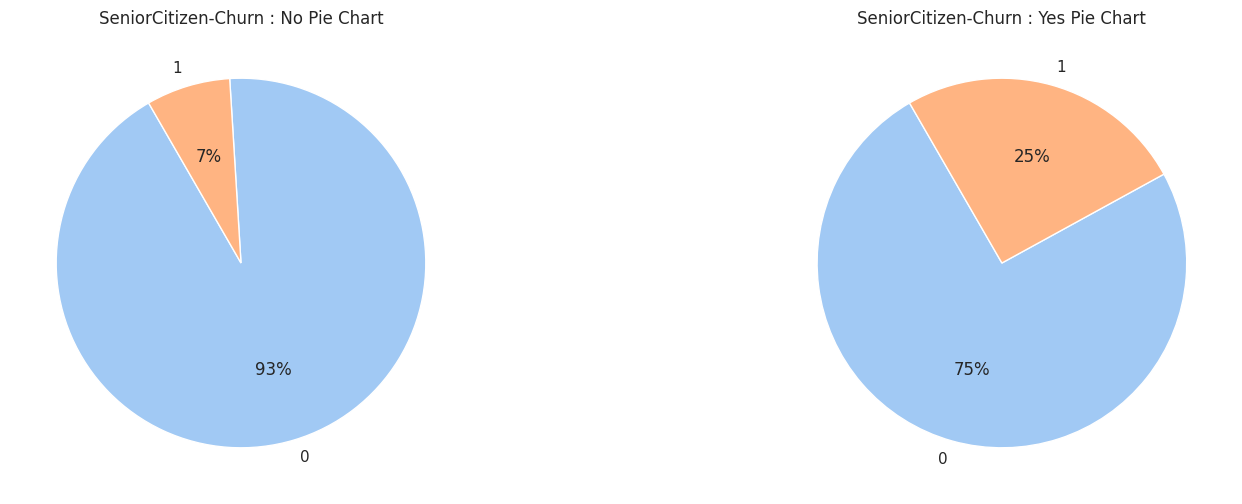

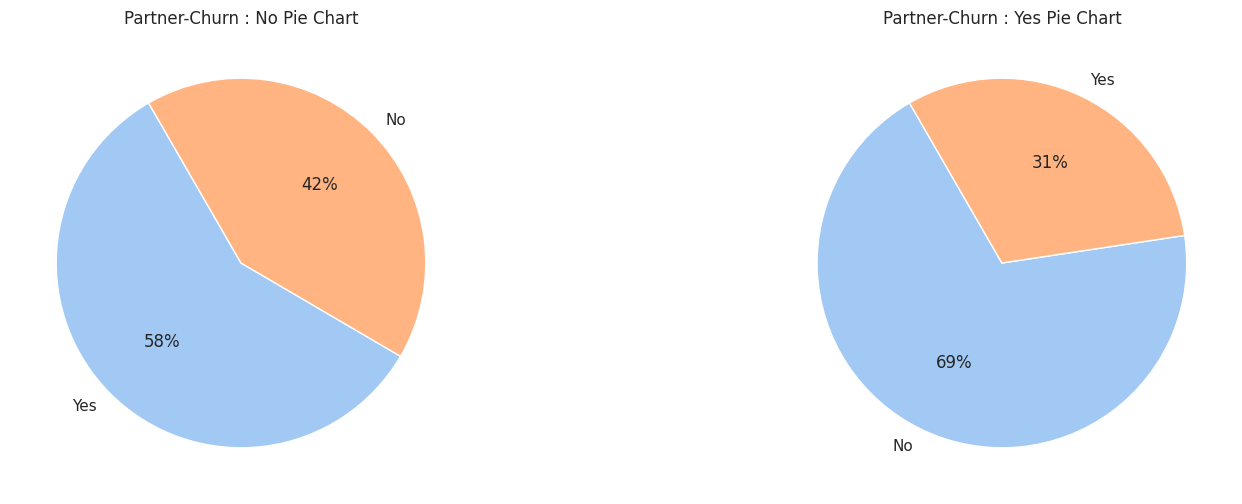

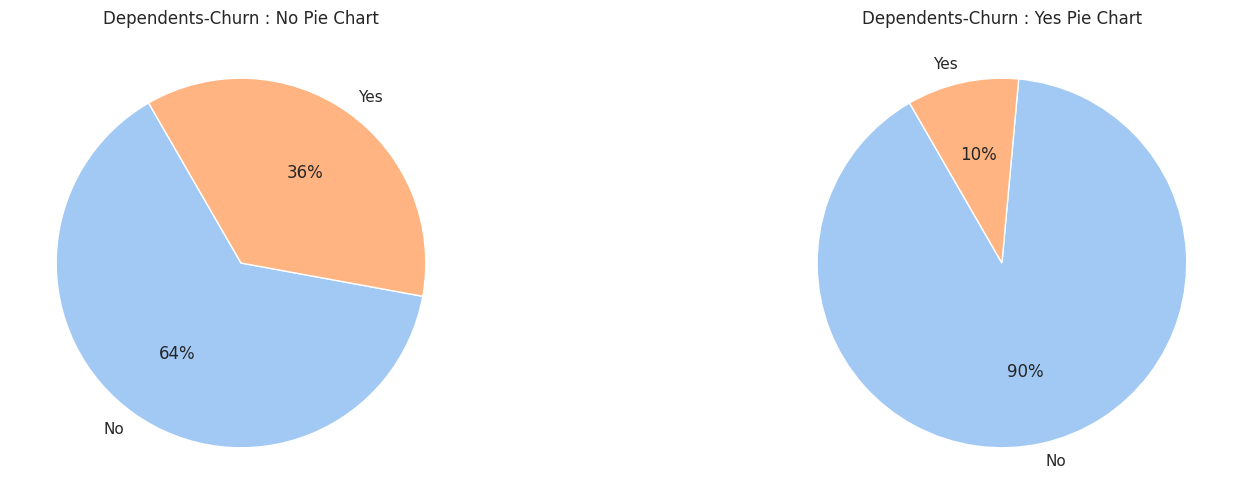

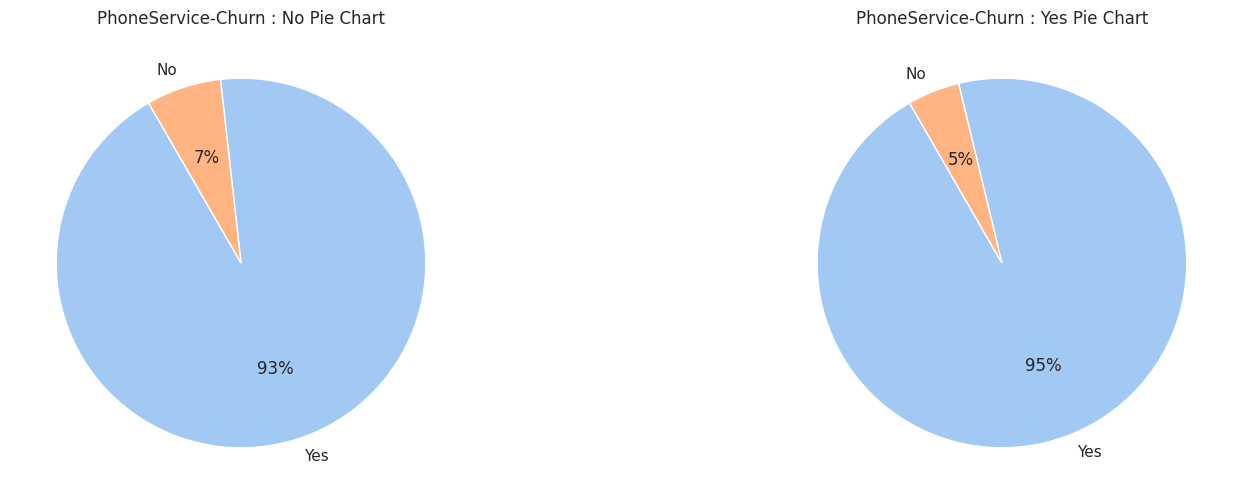

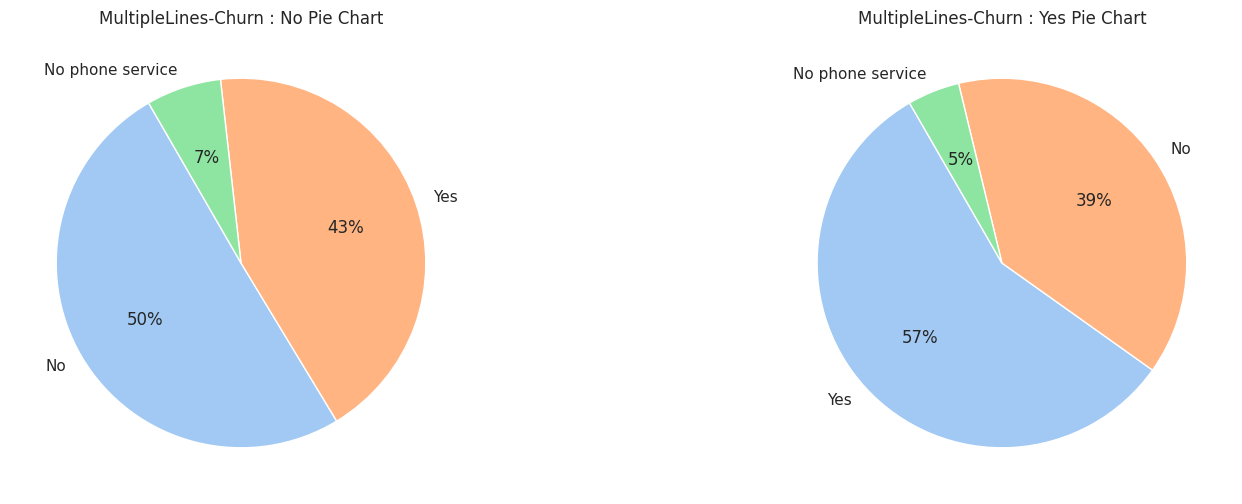

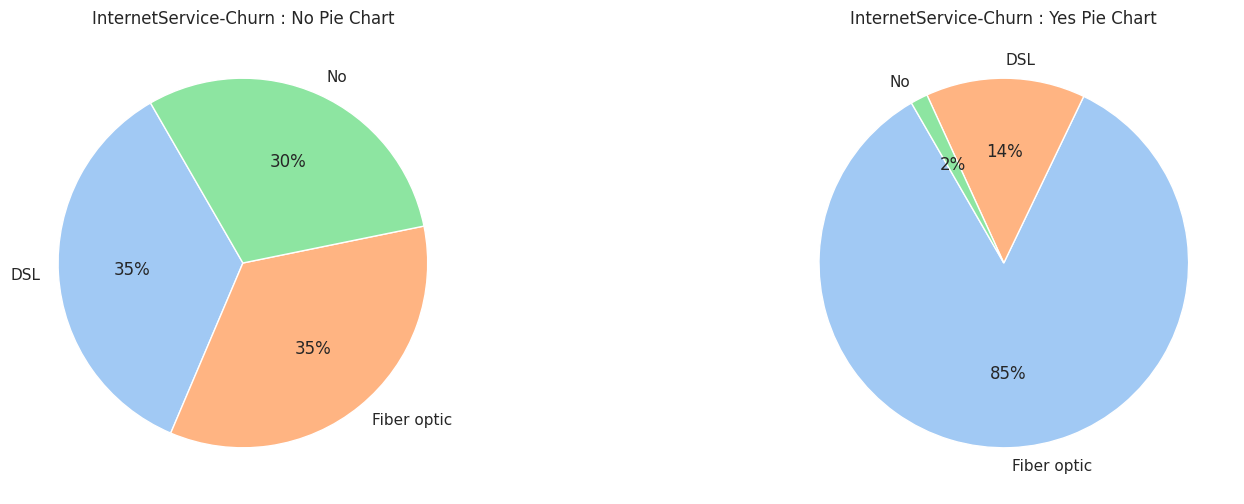

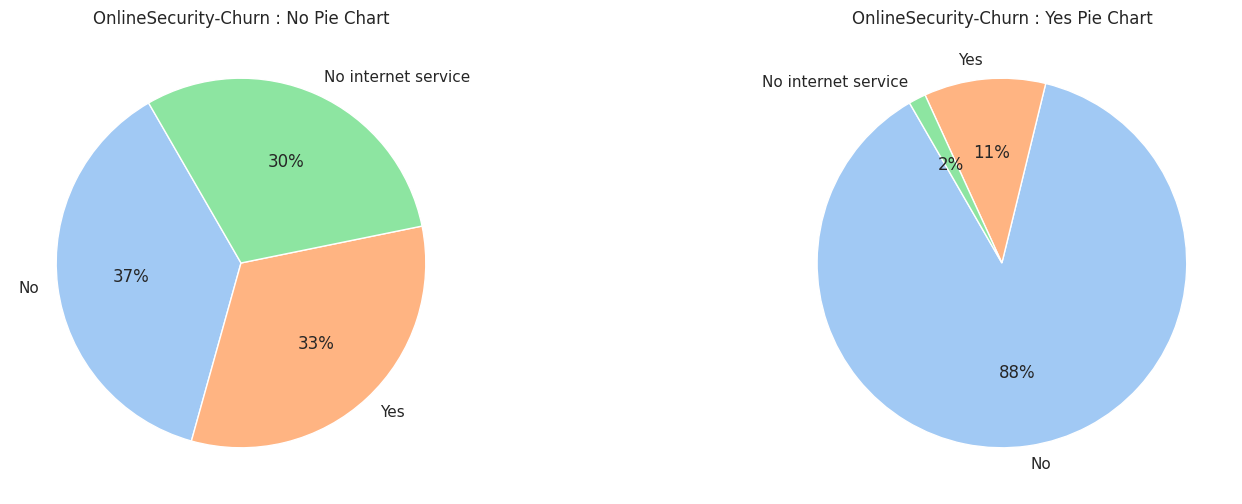

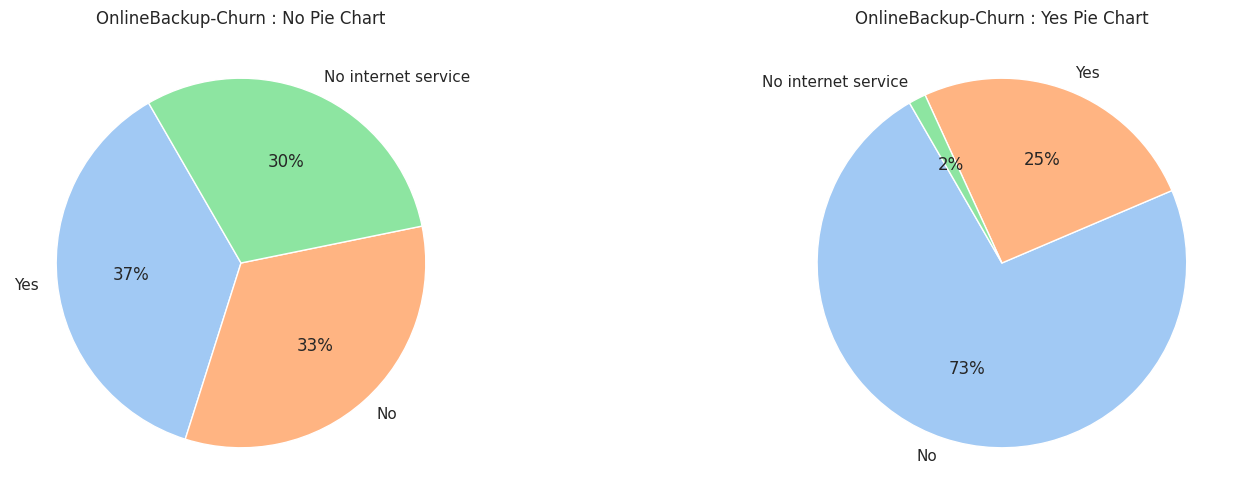

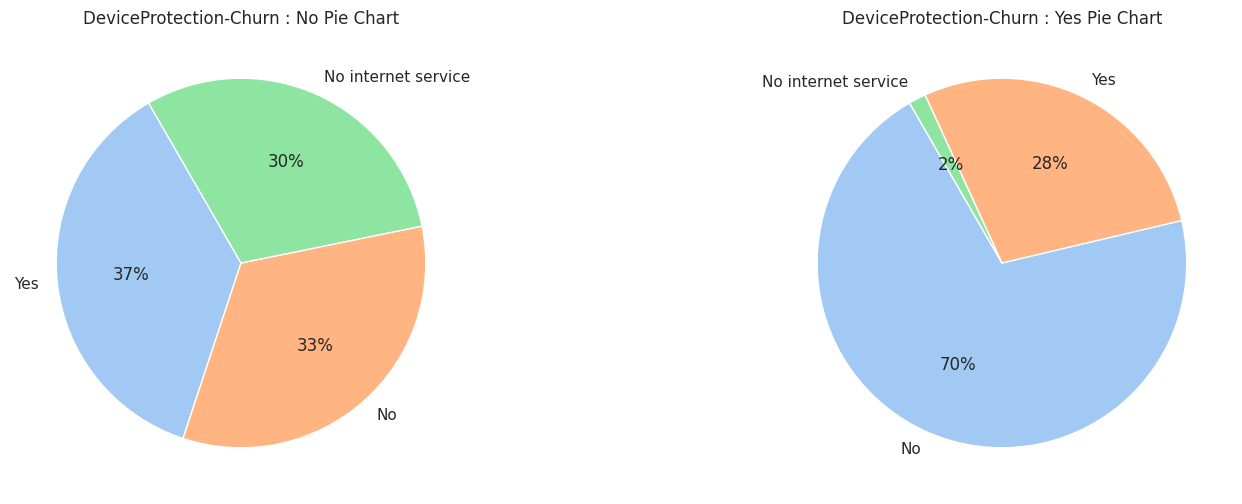

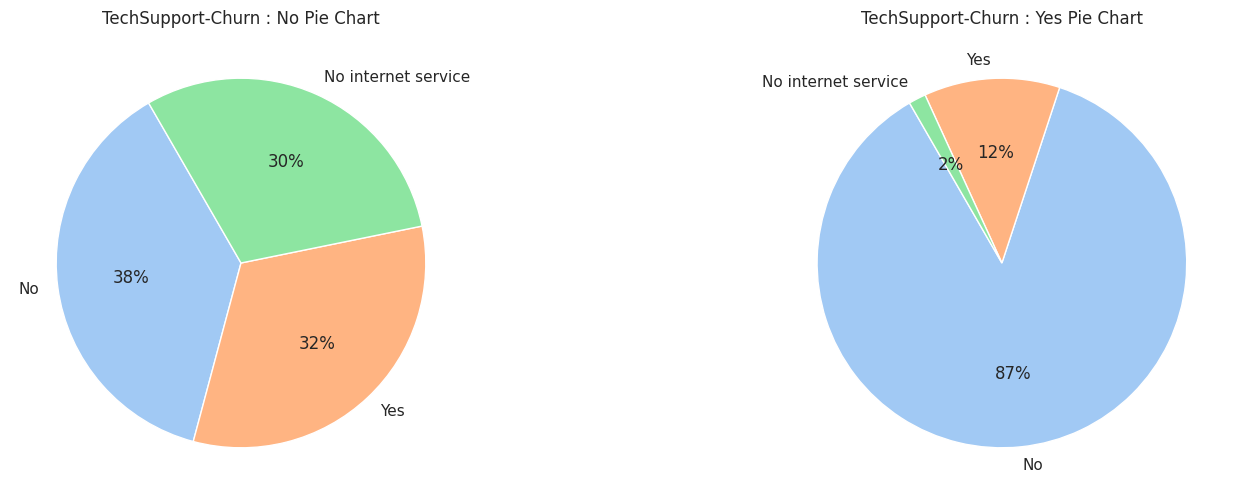

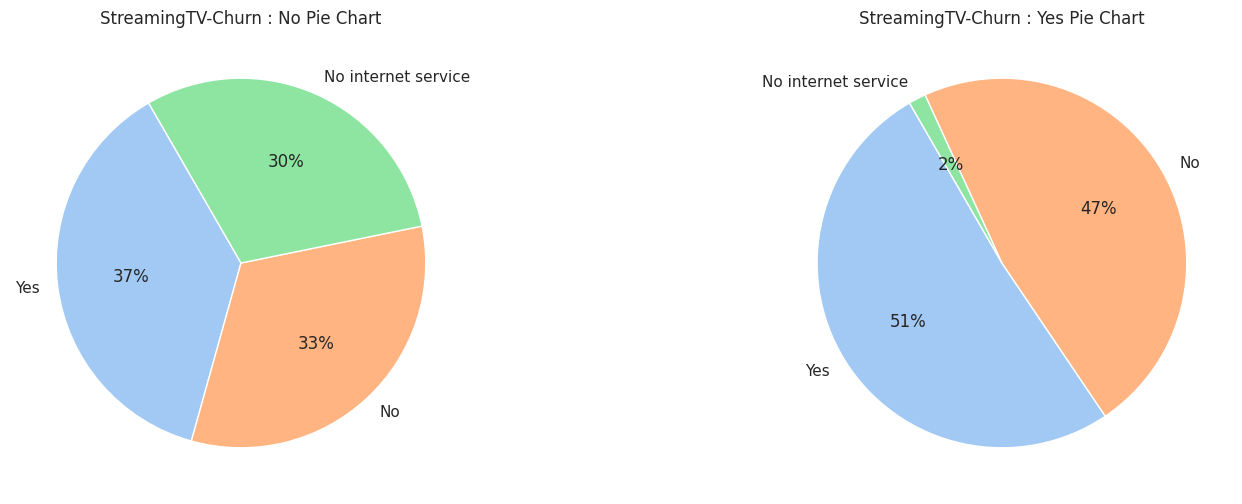

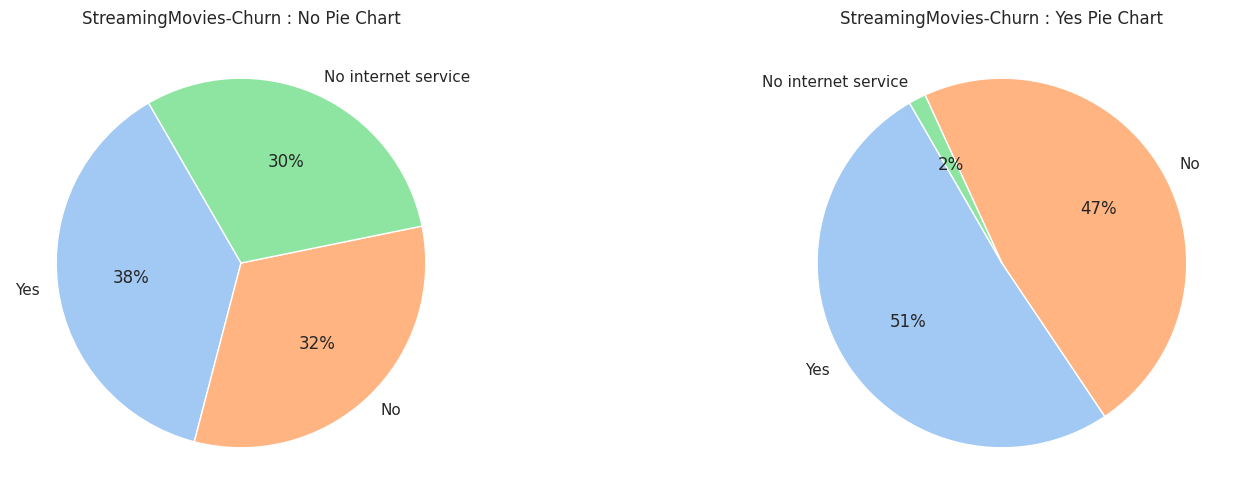

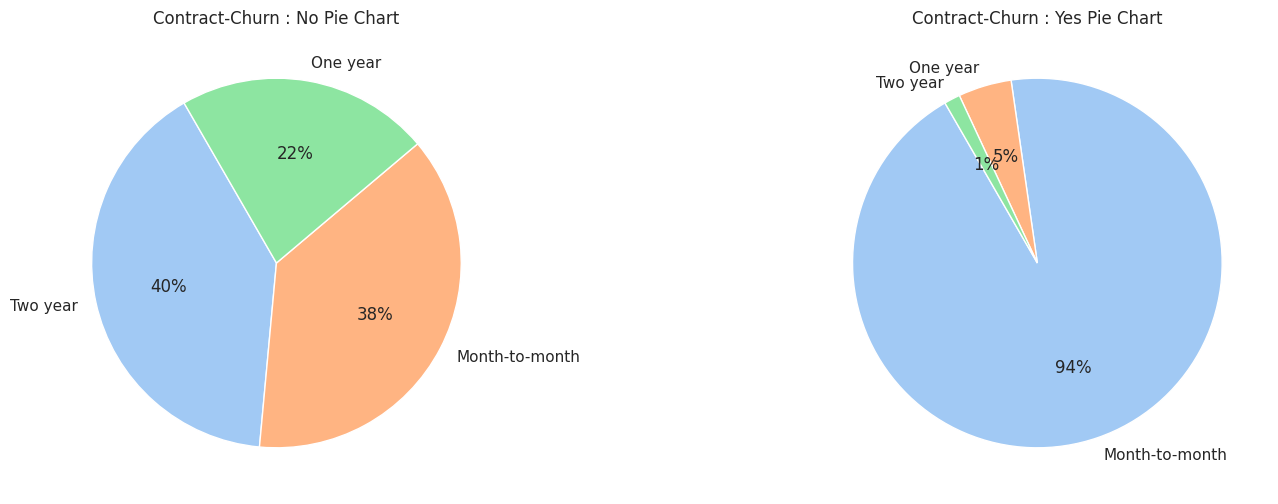

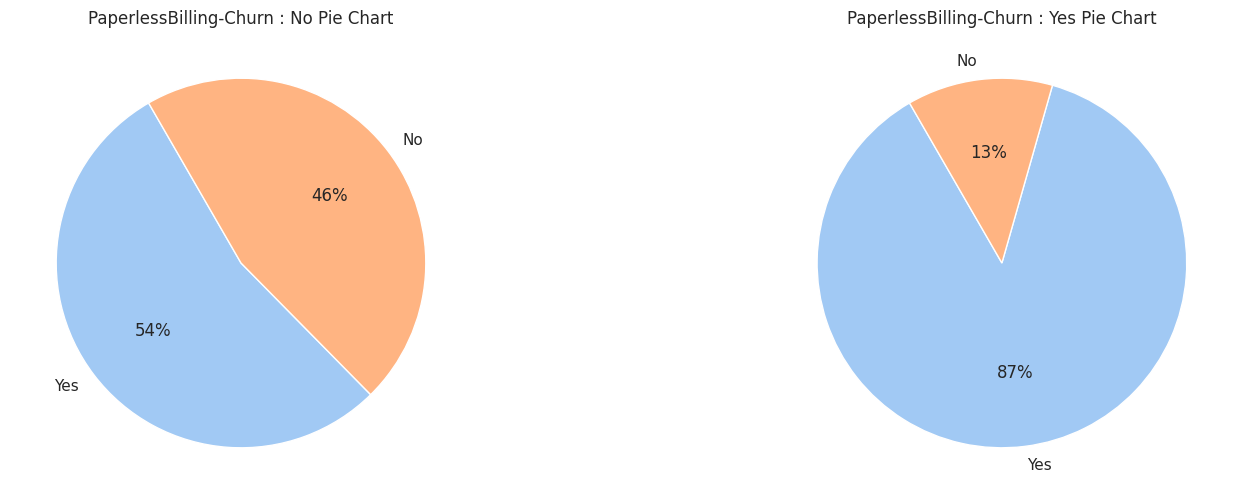

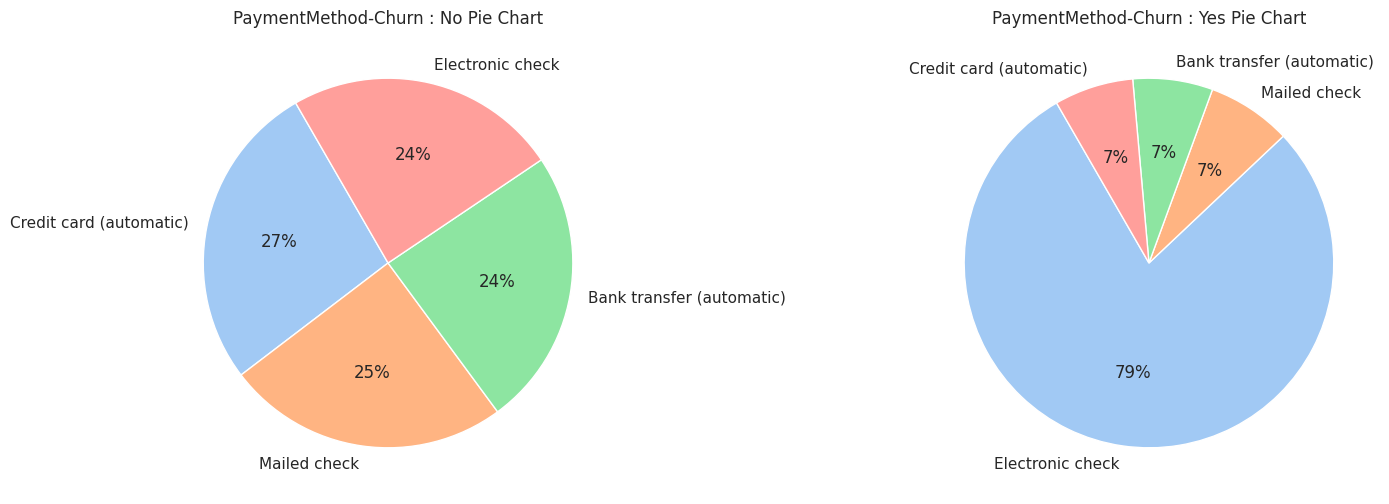

In [10]:
# categorical variable pie chart with target
ntarget = train_data[target_col].nunique()

for _i, _col in enumerate(cat_col_list):
    fig, axes = plt.subplots(1, ntarget, figsize=(18, 6), gridspec_kw={'width_ratios': [1 for _ in range(ntarget)]})
    sample_data = train_data[[_col, target_col]].groupby(target_col).value_counts(normalize=True)

    for _j, _tval in enumerate(train_data[target_col].unique()):    
        axes[_j].pie(sample_data[_tval], labels=sample_data[_tval].index, colors=colors[:sample_data[_tval].__len__()], autopct='%.0f%%', startangle=120)
        axes[_j].set_title(f'{_col}-{target_col} : {_tval} Pie Chart')
    
    plt.show()

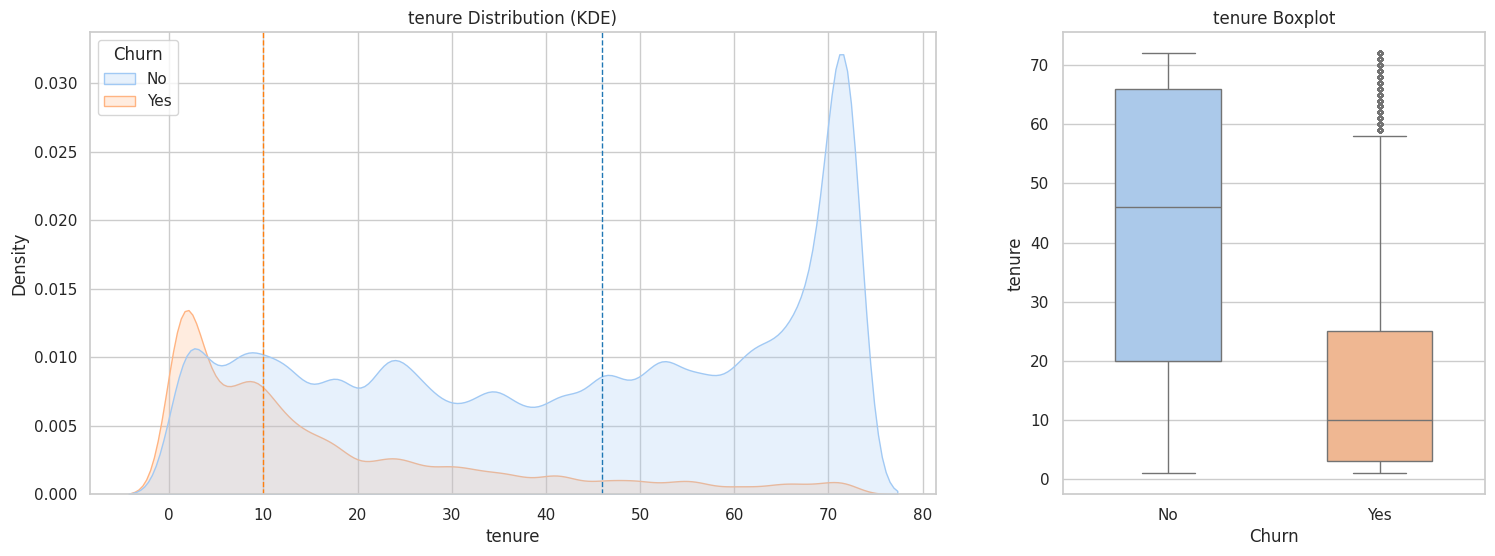

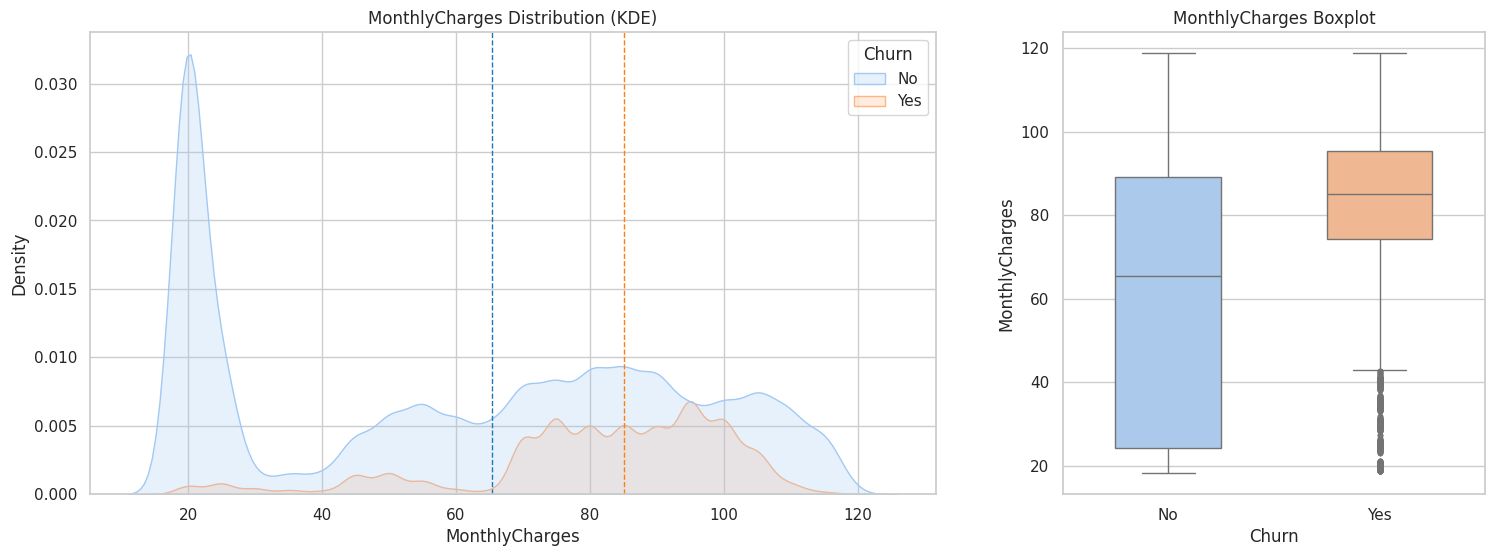

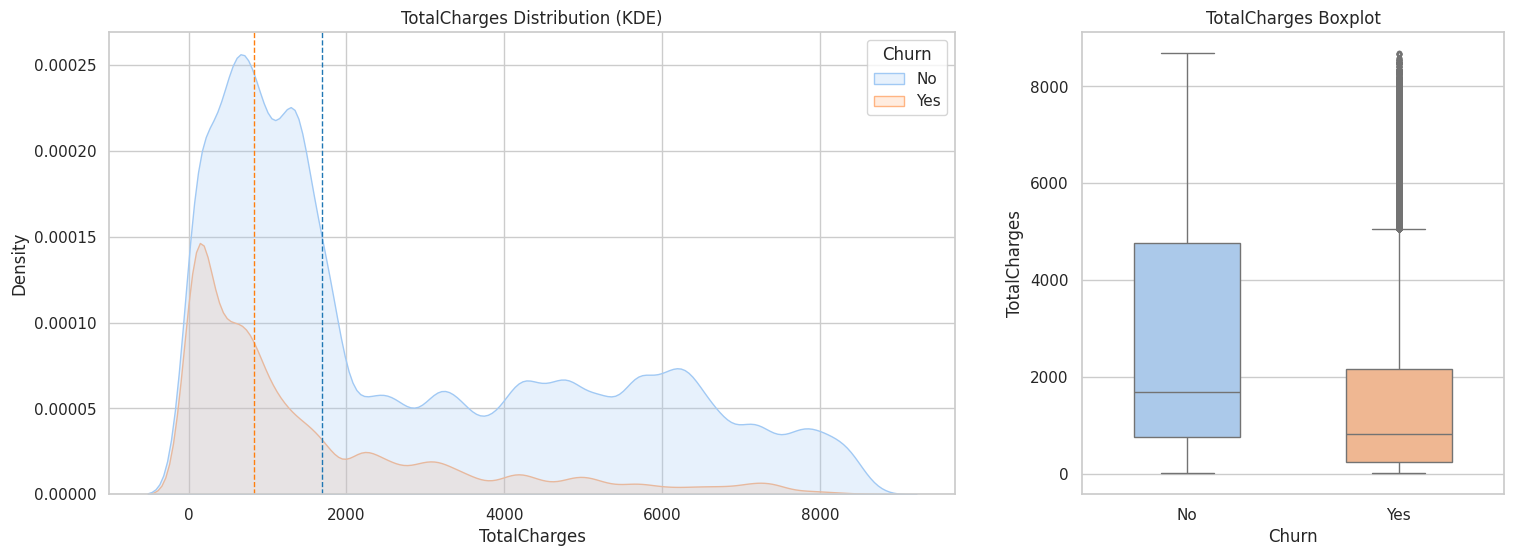

In [11]:
# numerical variable kde-box plot with target
colors = sns.color_palette('pastel')
lin_colors = sns.color_palette("tab10")
ntarget = train_data[target_col].nunique()

# train_data[num_col_list].hist(bins=100, figsize=(16,12))
for _col in num_col_list:
    fig, axes = plt.subplots(1, ntarget, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})
    sns.kdeplot(
        data=train_data, x=_col, hue=target_col, ax=axes[0], fill=True, palette=colors[:2])
    mid = train_data[[_col, target_col]].groupby(target_col).quantile(.5).to_dict()[_col]
    axes[0].set_title(f'{_col} Distribution (KDE)', fontsize=12,)
    for _j, _tval in enumerate(train_data[target_col].unique()):
        axes[0].axvline(x=mid[_tval], color=lin_colors[_j], linestyle='--', linewidth=1, label=f'{_tval}_midian')
    
    sns.boxplot(
        data=train_data, x=target_col, y=_col, hue=target_col, ax=axes[1], palette=colors[:2],
        orient='v', width=0.5, linewidth=1, fliersize=3, legend=False)
    axes[1].set_title(f'{_col} Boxplot', fontsize=12)

    plt.show()

In [12]:
yesno = {
    'Yes': 1,
    'No': 0,
}
train_data[target_col] = train_data[target_col].apply(lambda x: yesno[x])
global_stats = {'mean': train_data[target_col].mean(), 'median': train_data[target_col].median(), 'count': 0}

X = train_data.iloc[:, :-1]
y = train_data.pop(target_col)


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps = {}
        self.global_mean_freq = None
        self._feature_names = None 

    def set_output(self, *, transform=None):
        if transform is None or transform in ["pandas", "default"]:
            return self
        raise ValueError(f"Unsupported transform: {transform}")

    def fit(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self._feature_names = list(X_df.columns)
        self.global_mean_freq = 0.0 
        for col in self._feature_names: 
            freqs = X_df[col].value_counts(normalize=True).to_dict()
            self.freq_maps[col] = freqs
        return self

    def transform(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self._feature_names)
        X_encoded = pd.DataFrame()
        for col in X_df.columns:
            mapping = self.freq_maps.get(col, {})
            X_encoded[col] = X_df[col].map(mapping).fillna(self.global_mean_freq).astype(float)
        X_encoded.columns = [f'frq_enc__{c}' for c in X_encoded.columns] 
        return X_encoded

def target_stats(X, features, st_type, global_stats=global_stats):
    X_stat = pd.DataFrame()
    for c in features:
        c_st_dict = X.groupby(c)[target_col].agg([st_type]).to_dict()[st_type]
        X_stat[c] = X[c].map(c_st_dict).fillna(global_stats[st_type])
    return X_stat

In [13]:
minmax_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
     ('robust_scaling', RobustScaler())]
)
ordinal_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="most_frequent")),
     ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.int8))]
)
kbins_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
     ('kbins', KBinsDiscretizer(n_bins=10, strategy='uniform', encode='ordinal', random_state=seed))]
)
freqn_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
    ('freq', FrequencyEncoder())]
)
freqc_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="most_frequent")),
    ('freq', FrequencyEncoder())]
)
log_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
     ('log_trans', PowerTransformer(method='yeo-johnson')),
     ('robust_scaling', RobustScaler())]
)
square_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
     ('square_trans', FunctionTransformer(func=np.square, feature_names_out='one-to-one')),
     ('robust_scaling', RobustScaler())]
)
cube_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
     ('cube_trans', FunctionTransformer(func=lambda x: np.power(x, 3), feature_names_out='one-to-one')),
     ('robust_scaling', RobustScaler())]
)
sqrt_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
     ('sqrt_trans', FunctionTransformer(func=np.sqrt, feature_names_out='one-to-one')),
     ('robust_scaling', RobustScaler())]
)
cbrt_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
     ('cbrt_trans', FunctionTransformer(func=np.cbrt, feature_names_out='one-to-one')),
     ('robust_scaling', RobustScaler())]
)
median_pipeline_placeholder = Pipeline(
    [('imputer', SimpleImputer(strategy="median")),
     ('median_enc', FunctionTransformer(func=lambda x, features, stats, global_stats: target_stats(x, features, stats, 'median', global_stats), validate=False, feature_names_out='one-to-one'))]
)

In [14]:
def create_interactions(X):
    X = X.copy()
    # 서비스 관련
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    X['TotalServicesCount'] = (X[service_cols] == 'Yes').sum(axis=1)
    security_cols = ['OnlineSecurity', 'TechSupport']
    X['SecurityCount'] = (X[security_cols] == 'Yes').sum(axis=1)
    stream_cols = ['StreamingTV', 'StreamingMovies']
    X['StreamCount'] = (X[stream_cols] == 'Yes').sum(axis=1)
    X['StreamingAnd'] = (X['StreamingTV'] == 'Yes') & (X['StreamingMovies'] == 'Yes')
    # 가족 결합
    X['IsFamily'] = ((X['Partner'] == 'Yes') & (X['Dependents'] == 'Yes')).astype(int)
    # 유저 기간 대비 지출
    X['ChargesPerTenure'] = X['TotalCharges'] / (X['tenure'] + 1)
    X['ChargesPerTenureSq'] = X['TotalCharges'] / ((X['tenure'] + 1) ** 2)
    X['MoneyRedi'] = X['TotalCharges'] - X['tenure'] * X['MonthlyCharges']
    X['HighCharge_ShortContract'] = (X['MonthlyCharges'] > X['MonthlyCharges'].median()) & (X['Contract'] == 'Month-to-month')
    X['HighCharge_ShortContract'] = X['HighCharge_ShortContract'].astype(int)
    # 추가적인
    X['is_auto'] = X['PaymentMethod'].apply(lambda x: 'automatic' in x)
    X['tenureOver24'] = X['tenure'] >= 24
    X['Manual_Payment_Burden'] = (1 - X['is_auto']) * X['MonthlyCharges']
    return X

# 파이프라인에 추가할 변환기
interaction_transformer = FunctionTransformer(create_interactions)
add_num_col_list = [
    'ChargesPerTenure', 'MoneyRedi', 
    'TotalServicesCount', 'SecurityCount', 'StreamCount',
    'Manual_Payment_Burden',
]
add_cat_col_list = [
    'IsFamily', 'HighCharge_ShortContract', 'is_auto',
    'tenureOver24', 'StreamingAnd', 
]
num_col_list = num_col_list + [c for c in add_num_col_list if c in num_col_list]
cat_col_list = cat_col_list + [c for c in add_cat_col_list if c in cat_col_list]

# 파이프라인에 제거할 변환기
def feature_drop(X):
    X = X.copy()
    threshold = 2000
    
    low_importance_cols = data_dict['lgbm'][data_dict['lgbm']['Importance'] < threshold].Feature
    existing_cols = [c for c in low_importance_cols if c in X.columns]
    existing_cols = existing_cols + ['square__tenure', 'ordinal__Partner', 'ordinal__gender', 'ordinal__StreamingMovies', 'frqc__frq_enc__TechSupport', 
                                     'frqc__frq_enc__StreamingTV', 'remainder__is_auto', 'remainder__tenureOver24']
    existing_cols = [c for c in existing_cols if c in X.columns]
    # print(existing_cols)
    return X.drop(columns=existing_cols)

drop_transformer = FunctionTransformer(feature_drop)

# 파이프라인에 제거할 변환기
def add_intersection(X):
    X = X.copy()
    X['HighValue_Contract_Efficiency'] = X['ordinal__Contract'] * X['remainder__ChargesPerTenureSq']
    X['NonAuto_HighMonthly'] = (1 - X['remainder__is_auto']) * X['minmax__MonthlyCharges']
    X['No_Protection_Zero'] = ((X['ordinal__OnlineSecurity'] == 0) & (X['ordinal__TechSupport'] == 0)).astype(int)
    return X
add_transformer = FunctionTransformer(add_intersection)

target_enc_cols = ['Contract', 'PaymentMethod', 'HighCharge_ShortContract', 'InternetService',]

In [15]:
BaseTrans = ColumnTransformer([
    ("minmax", minmax_pipeline, num_col_list),
    # ("cluster", kbins_pipeline, num_col_list),
    ("frqn", freqn_pipeline, num_col_list),
    ("ordinal", ordinal_pipeline, cat_col_list),
    ("frqc", freqc_pipeline, cat_col_list),
    ("log", log_pipeline, num_col_list),
    ("square", square_pipeline, num_col_list),
    # ("cube", cube_pipeline, num_col_list),
    # ("sqrt", sqrt_pipeline, num_col_list),
    # ("cbrt", cbrt_pipeline, num_col_list),
    ('target', TargetEncoder(smoothing=20), target_enc_cols)
], remainder='passthrough')

In [16]:
preprocessor = Pipeline([
    ('interact', interaction_transformer),
    ('base', BaseTrans),
    ('add_interact', add_transformer),
    ('drop', drop_transformer),
])

In [17]:
# set model
GPU_ACC = True

# lr = LogisticRegression()
# xgb = xgb.XGBClassifier()
# lgbm = lgb.LGBMClassifier()
# catc = CatBoostClassifier()

# Model space
EstimatorStr = {1: 'lr', 2: 'xgb', 3: 'lgbm', 4: 'catc'}
# EstimatorMdl = {1: lr,   2: xgb,   3: lgbm,   4: catc}

In [18]:
def objective_lr(trial, X_tr, y_tr, X_val, y_val):
    static_params = {
        'solver': 'saga',
        'max_iter': 1000,
        'random_state': seed,
    }
    for _k, _v in static_params.items():
        trial.set_user_attr(_k, _v)

    params = {
        **static_params,
        'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l2', 'l1']),
    }
    model = LogisticRegression(**params)
    model.fit(X_tr, y_tr)
    
    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

def objective_xgb(trial, X_tr, y_tr, X_val, y_val):
    static_params = {
        'tree_method': 'hist',
        'n_jobs': -1,
        'device': 'cuda',
        'early_stopping_rounds': 100,
        'random_state': seed,
    }
    for _k, _v in static_params.items():
        trial.set_user_attr(_k, _v)

    params = {
        **static_params,
        'n_estimators': trial.suggest_int('n_estimators', 1000, 10000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

def objective_lgbm(trial, X_tr, y_tr, X_val, y_val):
    static_params = {
        'importance_type': 'gain',
        'verbose': -1,
        'n_jobs': -1,
        'random_state': seed,
    }
    for _k, _v in static_params.items():
        trial.set_user_attr(_k, _v)

    params = {
        **static_params,
        'n_estimators': trial.suggest_int('n_estimators', 1000, 10000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 1024),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, .8), #.73 인데 떨구기
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }
    early_stop = lgb.early_stopping(stopping_rounds=100)
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[early_stop],)
    
    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

def objective_cat(trial, X_tr, y_tr, X_val, y_val):
    static_params = {
        'verbose': False,
        'task_type': 'GPU',
        'random_state': seed,
    }
    for _k, _v in static_params.items():
        trial.set_user_attr(_k, _v)

    params = {
        **static_params,
        'iterations': trial.suggest_int('iterations', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 128, 255),
    }
    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)
    
    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

EstimatorTun = {1: objective_lr, 2: objective_xgb, 3: objective_lgbm, 4: objective_cat}

In [19]:
def oof_lr(best_params, X_tr, y_tr, X_val, X_test):
    model = LogisticRegression(**best_params)
    model.fit(X_tr, y_tr)
    val_preds = model.predict(X_val)
    preds = model.predict_proba(X_val)[:, 1]
    test_preds = model.predict_proba(X_test)[:, 1]
    
    return val_preds, test_preds, preds

def oof_xgb(best_params, X_tr, y_tr, X_val, X_test):
    # best_params = {
    #   "n_estimators": 2977,
    #   "learning_rate": 0.01709667830883939,
    #   "max_depth": 5,
    #   "min_child_weight": 3,
    #   "subsample": 0.9169749669876814,
    #   "colsample_bytree": 0.6281077726911428,
    #   "gamma": 0.01391578004883259,
    #   "tree_method": "hist",
    #   "n_jobs": -1,
    #   "device": "cuda",
    #   "early_stopping_rounds": 100,
    #   "random_state": 2026
    # }
    model = xgb.XGBClassifier(**best_params)
    
    model.fit(X_tr, y_tr, 
              eval_set=[(X_val, y_val)], 
              verbose=False)
    
    preds = model.predict_proba(X_val)[:, 1]
    test_preds = model.predict_proba(X_test)[:, 1]

    scores = model.get_booster().get_score(importance_type='gain')
    importance_df = pd.Series(scores).sort_values(ascending=False)
    importance_df.to_csv('importance_xgb.csv')
    
    return test_preds, preds

def oof_lgbm(best_params, X_tr, y_tr, X_val, X_test):
    early_stop = lgb.early_stopping(stopping_rounds=100)
    model = lgb.LGBMClassifier(**best_params)
    
    model.fit(X_tr, y_tr, 
              eval_set=[(X_val, y_val)],
              callbacks=[early_stop])
    
    preds = model.predict_proba(X_val)[:, 1]
    test_preds = model.predict_proba(X_test)[:, 1]

    importance_df = pd.DataFrame({
        'Feature': model.feature_name_,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    importance_df.to_csv(f'importance_lgbm.csv') # lgbm
    
    return test_preds, preds

def oof_cat(best_params, X_tr, y_tr, X_val, X_test):
    model = CatBoostClassifier(**best_params)
    
    model.fit(X_tr, y_tr, 
              eval_set=(X_val, y_val), 
              early_stopping_rounds=100, 
              verbose=False)
    
    preds = model.predict_proba(X_val)[:, 1]
    test_preds = model.predict_proba(X_test)[:, 1]

    importance_df = pd.DataFrame({
        'Feature': model.feature_names_,
        'Importance': model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)
    importance_df.to_csv(f'importance_cat.csv') 
    
    return test_preds, preds

EstimatorOOF = {1: oof_lr, 2: oof_xgb, 3: oof_lgbm, 4: oof_cat}

In [20]:
### Find best params
TUNING = True
FOLDS = 5

EST_IDS = [2, 3] # {1: 'lr', 2: 'xgb', 3: 'lgbm', 4: 'catc'}
est_dict = dict()
oof_dict = dict()

for est_id in EST_IDS:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    best_params = dict()
    
    if TUNING:
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
        preprocessor_copy = deepcopy(preprocessor)
        preprocessor_copy.set_output(transform='pandas')
        
        X_tr = preprocessor_copy.fit_transform(X_tr, y_tr)
        X_val = preprocessor_copy.transform(X_val)
        if est_id == 4:
            pass
        study = optuna.create_study(direction="maximize")
        study.optimize(lambda trial: EstimatorTun[est_id](trial, X_tr, y_tr, X_val, y_val), n_trials=30)
        best_params = {**study.best_params, **study.best_trial.user_attrs}
        
        best_info = {
            "best_score": study.best_value,
            "best_params": best_params,
            "model_name": f"{EstimatorStr[est_id]}" # 예시
        }
        with open(f"best_config_{EstimatorStr[est_id]}.json", "w") as f:
            json.dump(best_info, f, indent=4)
        
        print("Best Parameters:", best_params)

    oof_preds = np.zeros(len(X))
    final_test_preds = np.zeros(len(test_data))
    skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=seed)
    for _id, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        preprocessor_copy = deepcopy(preprocessor)
        preprocessor_copy.set_output(transform='pandas')

        X_tr = preprocessor_copy.fit_transform(X_tr, y_tr)
        X_val = preprocessor_copy.transform(X_val)
        test_scaled = preprocessor_copy.transform(test_data)

        if est_id == 4:
            pass
        test_preds, preds = EstimatorOOF[est_id](best_params, X_tr, y_tr, X_val, test_scaled)
        oof_preds[val_idx] = preds
        final_test_preds += test_preds / skf.n_splits
        fold_score = roc_auc_score(y_val, preds)

        print(f"Fold {_id}  Score: {fold_score:.4f}")

    oof_accuracy = roc_auc_score(y, oof_preds)
    print(f"\n[최종 결과] OOF 전체 정확도: {oof_accuracy:.4f}")
    model_sub = deepcopy(submission)
    model_sub[target_col] = final_test_preds
    model_sub.to_csv(f'submission_{EstimatorStr[est_id]}.csv', index=False)
    est_dict[est_id] = final_test_preds
    oof_dict[est_id] = oof_preds

final_oof_probs = oof_dict[2] * .55 + oof_dict[3] * .45
final_score = roc_auc_score(y, final_oof_probs)

final_test_probs_vote = est_dict[2] * .55 + est_dict[3] * .45

print(f"최종 앙상블 OOF AUC: {final_score:.5f}")
model_sub = deepcopy(submission)
model_sub[target_col] = final_test_probs_vote
model_sub.to_csv(f'submission_vote.csv', index=False)

[I 2026-03-16 00:17:03,442] A new study created in memory with name: no-name-fa96847a-1f4f-4ac8-981e-17364ec6be20
[I 2026-03-16 00:17:10,545] Trial 0 finished with value: 0.9161462257961939 and parameters: {'n_estimators': 8515, 'learning_rate': 0.03425234220795714, 'max_depth': 8, 'min_child_weight': 10, 'subsample': 0.646933266656862, 'colsample_bytree': 0.6864615854842318, 'gamma': 3.3390687473773127e-06}. Best is trial 0 with value: 0.9161462257961939.
[I 2026-03-16 00:17:32,144] Trial 1 finished with value: 0.9165205581452409 and parameters: {'n_estimators': 5264, 'learning_rate': 0.010029895181567237, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.6107868157817176, 'colsample_bytree': 0.6337929356901046, 'gamma': 1.1955564854311476e-07}. Best is trial 1 with value: 0.9165205581452409.
[I 2026-03-16 00:17:38,772] Trial 2 finished with value: 0.916381876690318 and parameters: {'n_estimators': 8811, 'learning_rate': 0.035532554824816945, 'max_depth': 6, 'min_child_weight': 2

Best Parameters: {'n_estimators': 7973, 'learning_rate': 0.007477508693809318, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.9117309293274725, 'colsample_bytree': 0.9989040663551262, 'gamma': 7.410728143774498e-08, 'tree_method': 'hist', 'n_jobs': -1, 'device': 'cuda', 'early_stopping_rounds': 100, 'random_state': 2026}
Fold 0  Score: 0.9157
Fold 1  Score: 0.9181
Fold 2  Score: 0.9170
Fold 3  Score: 0.9164
Fold 4  Score: 0.9175

[최종 결과] OOF 전체 정확도: 0.9169


[I 2026-03-16 00:28:34,067] A new study created in memory with name: no-name-ddc3dd95-bc96-4e7c-9ac3-356b1627c142


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[100]	valid_0's binary_logloss: 0.298808


[I 2026-03-16 00:28:46,848] Trial 0 finished with value: 0.9156754099609635 and parameters: {'n_estimators': 8874, 'learning_rate': 0.1292370962126497, 'num_leaves': 161, 'max_depth': 9, 'reg_alpha': 0.1085173130982143, 'reg_lambda': 0.43375606870859407, 'min_child_samples': 19, 'feature_fraction': 0.503313284367882, 'bagging_fraction': 0.890333771298152, 'bagging_freq': 2}. Best is trial 0 with value: 0.9156754099609635.


...

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1068]	valid_0's binary_logloss: 0.297637


[I 2026-03-16 01:09:13,468] Trial 28 finished with value: 0.9164137746870078 and parameters: {'n_estimators': 1070, 'learning_rate': 0.02245695448338504, 'num_leaves': 417, 'max_depth': 6, 'reg_alpha': 0.6426198850724167, 'reg_lambda': 0.7265527657126832, 'min_child_samples': 45, 'feature_fraction': 0.6261482575480511, 'bagging_fraction': 0.7792284101396881, 'bagging_freq': 4}. Best is trial 19 with value: 0.9165453553436751.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[424]	valid_0's binary_logloss: 0.298332


[I 2026-03-16 01:09:47,405] Trial 29 finished with value: 0.916004203541086 and parameters: {'n_estimators': 4682, 'learning_rate': 0.03470988194123126, 'num_leaves': 224, 'max_depth': 9, 'reg_alpha': 0.7676491586015198, 'reg_lambda': 0.3807210051362586, 'min_child_samples': 54, 'feature_fraction': 0.7600888476063976, 'bagging_fraction': 0.8760711844827604, 'bagging_freq': 1}. Best is trial 19 with value: 0.9165453553436751.


Best Parameters: {'n_estimators': 2650, 'learning_rate': 0.022015010502993843, 'num_leaves': 386, 'max_depth': 5, 'reg_alpha': 0.9669004817213445, 'reg_lambda': 0.7759146388651668, 'min_child_samples': 45, 'feature_fraction': 0.6788736797531749, 'bagging_fraction': 0.8387048800199188, 'bagging_freq': 4, 'importance_type': 'gain', 'verbose': -1, 'n_jobs': -1, 'random_state': 2026}
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2042]	valid_0's binary_logloss: 0.298892
Fold 0  Score: 0.9157
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2649]	valid_0's binary_logloss: 0.295134
Fold 1  Score: 0.9181
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2105]	valid_0's binary_logloss: 0.296199
Fold 2  Score: 0.9171
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1994]	valid_0's binary_